# Исследовательский анализ данных сервиса «Яндекс Афиша»

- **Автор:** Кривенко Виктория  
- **Дата:** 24.09.2026

### Цели и задачи проекта

**Цель проекта:** провести исследовательский анализ данных о бронировании билетов на сервисе «Яндекс Афиша» за период с 1 июня по 31 октября 2024 года, чтобы выявить изменения пользовательского спроса и предпочтений осенью 2024 года, а также сравнить поведение пользователей мобильных и стационарных устройств.

**Задачи проекта:**
- загрузить и изучить исходные данные;
- проверить качество данных и выполнить необходимую предобработку;
- привести выручку к единой валюте — российскому рублю;
- исследовать сезонные изменения количества заказов и структуры пользовательского спроса;
- сравнить летний и осенний периоды по типам мероприятий, устройствам и возрастным категориям;
- изучить изменение средней выручки с продажи одного билета;
- проанализировать активность пользователей осенью 2024 года и недельную цикличность;
- определить наиболее популярные регионы, билетных партнёров и мероприятия;
- проверить гипотезы о различиях в поведении пользователей мобильных и стационарных устройств;
- сформулировать основные выводы и рекомендации для развития сервиса.


### Описание данных

В проекте используются данные о бронировании билетов на сервисе «Яндекс Афиша» за период с **1 июня по 31 октября 2024 года**.

Для анализа предоставлены три датасета:

**`final_tickets_orders_df.csv`** — информация о заказах билетов, совершённых с мобильных и стационарных устройств:
- `order_id` — уникальный идентификатор заказа;
- `user_id` — уникальный идентификатор пользователя;
- `created_dt_msk` — дата создания заказа;
- `created_ts_msk` — дата и время создания заказа;
- `event_id` — идентификатор мероприятия;
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- `age_limit` — возрастное ограничение мероприятия;
- `currency_code` — валюта оплаты;
- `device_type_canonical` — тип устройства;
- `revenue` — выручка от заказа;
- `service_name` — название билетного оператора.
- `tickets_count` — количество купленных билетов;
- `total` — общая сумма заказа;
- `days_since_prev` — количество дней с предыдущей покупки пользователя.

**`final_tickets_events_df.csv`** - информация о мероприятиях, их организаторах и площадках проведения:
- `event_id` — уникальный идентификатор мероприятия;
- `event_name` — название мероприятия;
- `event_type_description` — описание типа мероприятия;
- `event_type_main` — основной тип мероприятия;
- `organizers` — организаторы мероприятия;
- `region_name` — регион;
- `city_name` — город;
- `venue_id` — идентификатор площадки;
- `venue_name` — название площадки;
- `venue_address` — адрес площадки.

Из данных исключены мероприятия типа «фильм».

**`final_tickets_tenge_df.csv`** — данные о курсе казахстанского тенге к российскому рублю за 2024 год. Данные необходимы для приведения выручки в тенге к единой валюте — российскому рублю:
- `nominal` — номинал, равный 100 тенге;
- `data` — дата курса;
- `curs` — курс тенге к рублю;
- `cdx` — обозначение валюты (`kzt`).

### Содержание проекта

1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
4. Статистический анализ данных
5. Общий вывод и рекомендации

## 1. Загрузка данных и знакомство с ними
- Загружаем нужные библиотеки и датасеты

In [1]:
# импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Выгружаем данные из датасетов final_tickets_orders_df.csv, final_tickets_events_df.csv и final_tickets_tenge_df.csv 
# в датафреймы rest_info и rest_price
orders_info = pd.read_csv('/datasets/final_tickets_orders_df.csv')
events_info = pd.read_csv('/datasets/final_tickets_events_df.csv')
tenge_curs = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

Познакомимся с данными датасета `final_tickets_orders_df.csv` - выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
orders_info.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [4]:
# Выводим информацию о датафрейме
orders_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

Датасет `final_tickets_orders_df.csv` содержит **290 849 строк** и **14 столбцов**. Данные соответствуют описанию проекта и содержат информацию о заказах билетов, пользователях, мероприятиях, выручке, количестве билетов, типе устройства и времени оформления заказа.

После первичного анализа данных можно сделать следующие выводы:

- названия столбцов уже приведены к единому стилю и не требуют переименования;
- пропуски присутствуют только в столбце `days_since_prev` — 21 940 значений; это соответствует описанию данных, поскольку для пользователей без предыдущей покупки значение отсутствует;
- столбцы `created_dt_msk` и `created_ts_msk` имеют тип object, поэтому на этапе предобработки их необходимо преобразовать в тип datetime;
- количественные показатели `revenue`, `total` и `tickets_count` имеют подходящие числовые типы данных;
- столбец `days_since_prev` имеет тип float64, что связано с наличием пропусков; при дальнейшей обработке необходимо учитывать эту особенность;
- на следующем этапе необходимо дополнительно проверить значения в категориальных столбцах, распределение количественных показателей и наличие выбросов;
- также следует проверить данные на явные и неявные дубликаты.

Познакомимся с данными датасета `final_tickets_events_df.csv` - выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [5]:
# Выводим первые строки датафрейма на экран
events_info.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [6]:
# Выводим информацию о датафрейме
events_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


Датасет `final_tickets_events_df.csv` содержит **22 427 строк и 11 столбцов**. Данные соответствуют описанию проекта и содержат информацию о мероприятиях, их типах, организаторах, регионах, городах и площадках проведения.

После первичного анализа данных можно сделать следующие выводы:

- названия столбцов уже приведены к единому стилю и не требуют переименования;
- пропуски в данных отсутствуют — все 11 столбцов заполнены полностью;
- типы данных соответствуют содержимому столбцов: идентификаторы `event_id`, `city_id` и `venue_id` имеют целочисленный тип, остальные признаки представлены строковыми значениями;
- столбцы `event_type_main`, `organizers`, `region_name`, `city_name` и `venue_name` являются категориальными признаками, поэтому на этапе предобработки необходимо изучить представленные в них значения и проверить наличие неявных дубликатов;
- на следующем этапе необходимо проверить данные на явные и неявные дубликаты, а также изучить уникальные значения категориальных признаков.

Познакомимся с данными датасета `final_tickets_tenge_df.csv` - выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [7]:
# Выводим первые строки датафрейма на экран
tenge_curs.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [8]:
# Выводим информацию о датафрейме
tenge_curs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Датасет `final_tickets_tenge_df.csv` содержит **357 строк и 4 столбца**. Данные содержат информацию о курсе казахстанского тенге к российскому рублю за 2024 год и необходимы для конвертации выручки из тенге в рубли.

После первичного анализа данных можно сделать следующие выводы:

- пропуски в данных отсутствуют — все 357 строк полностью заполнены;
- столбцы `nominal` и `curs` имеют числовые типы данных, соответствующие их содержимому;
- столбцы `data` и `cdx` имеют тип `object`; столбец `data` необходимо преобразовать в формат `datetime` на этапе предобработки;
- значение `nominal` соответствует 100 тенге, что необходимо учитывать при расчёте курса для конвертации выручки;

## 2. Предобработка данных и подготовка их к исследованию

### 2.1 Проверка пропусков

In [9]:
# Проверяем пропуски во всех трёх датафреймах
print('orders_info:')
print(orders_info.isna().sum())
print()
print('events_info:')
print(events_info.isna().sum())
print()
print('tenge_curs:')
print(tenge_curs.isna().sum())

orders_info:
order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64

events_info:
event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64

tenge_curs:
data       0
nominal    0
curs       0
cdx        0
dtype: int64


Пропуски есть только в столбце `days_since_prev` (21 940 значений) — это ожидаемо: значение отсутствует у пользователей, которые совершают первую покупку. Остальные столбцы во всех трёх датафреймах заполнены полностью, **выгрузка из SQL прошла корректно.**

### 2.2 Объединение датафреймов

Объединяем заказы с информацией о мероприятиях сразу, чтобы дальше проводить всю предобработку на одном датафрейме.

In [10]:
# Соединяем данные в единый датафрейм df
df = orders_info.merge(events_info, on='event_id', how='left')

# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290849 non-null  int64  
 1   user_id                 290849 non-null  object 
 2   created_dt_msk          290849 non-null  object 
 3   created_ts_msk          290849 non-null  object 
 4   event_id                290849 non-null  int64  
 5   cinema_circuit          290849 non-null  object 
 6   age_limit               290849 non-null  int64  
 7   currency_code           290849 non-null  object 
 8   device_type_canonical   290849 non-null  object 
 9   revenue                 290849 non-null  float64
 10  service_name            290849 non-null  object 
 11  tickets_count           290849 non-null  int64  
 12  total                   290849 non-null  float64
 13  days_since_prev         268909 non-null  float64
 14  event_name          

После объединения датафреймов в некоторых столбцах образовались пропуски — это значит, что для части заказов не нашлось соответствующего мероприятия. Проверим, сколько таких заказов и с чем это может быть связано.

In [11]:
# Считаем, сколько заказов осталось без информации о мероприятии после объединения
print('Заказов без данных о событии:', df['event_type_main'].isna().sum())

# Проверяем, не связаны ли эти заказы с кинопоказами (cinema_circuit)
df[df['event_type_main'].isna()]['cinema_circuit'].value_counts()

Заказов без данных о событии: 238


нет    238
Name: cinema_circuit, dtype: int64

In [12]:
# Смотрим, скольким уникальным мероприятиям соответствуют эти заказы
missing_event_ids = df[df['event_type_main'].isna()]['event_id'].unique()
print('Уникальных event_id без описания:', len(missing_event_ids))

Уникальных event_id без описания: 19


In [13]:
# Удаляем заказы, для которых не нашлось информации о мероприятии
df = df.dropna(subset=['event_type_main']).reset_index(drop=True)

# Смотрим сколько осталось строк и столбцов после удаления
df.shape

(290611, 24)

После объединения датафреймов в 238 заказах не нашлось информации о мероприятии — эти заказы относятся всего к 19 уникальным `event_id`, которых нет в `events_info`. Заказы не связаны с кинопоказами (`cinema_circuit` = 'нет' у всех), значит дело не в исключении фильмов из справочника, а в том, что часть событий просто отсутствует в выгрузке `events_info`. 

Поскольку для дальнейшего анализа (тип мероприятия, регион, площадка) эта информация необходима, такие заказы были удалены. Итоговый датафрейм `df` содержит **290 611 строк.**

### 2.3 Изучение категориальных значений

In [14]:
# Смотрим, какие категории есть в ключевых категориальных столбцах orders
for col in ['currency_code', 'device_type_canonical', 'cinema_circuit', 'age_limit']:
    print(col)
    print(df[col].value_counts())
    print()

currency_code
rub    285542
kzt      5069
Name: currency_code, dtype: int64

device_type_canonical
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64

cinema_circuit
нет           289213
Другое          1261
КиноСити         122
Москино            7
Киномакс           7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64

age_limit
16    78556
12    62474
0     61487
6     52161
18    35933
Name: age_limit, dtype: int64



In [15]:
# Смотрим категории в столбцах events
for col in ['event_type_main', 'event_type_description']:
    print(col)
    print(df[col].value_counts())
    print()

event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

event_type_description
концерт                   112049
событие                    58605
спектакль                  50592
шоу                        13626
спорт                      12837
мюзикл                      9919
спортивное мероприятие      9074
балет                       5998
выставка                    5876
цирковое шоу                5327
фестиваль                   4273
опера                       1314
ёлка                         945
музыкальный спектакль        140
кукольный спектакль           13
экскурсия                      8
оперетта                       7
подарок                        4
снегурочка                     3
рок-мюзикл                     1
Name: event_type_description, dtype: int64



In [16]:
# Для столбцов с большим числом уникальных значений смотрим только их количество
for col in ['region_name', 'city_name', 'organizers', 'venue_name']:
    print(col, '-', df[col].nunique(), 'уникальных значений')

region_name - 81 уникальных значений
city_name - 352 уникальных значений
organizers - 4293 уникальных значений
venue_name - 3217 уникальных значений


Проверка категориальных столбцов показала, что все значения корректны и соответствуют описанию данных — скрытых пропусков под видом «unknown» или пустых значений нет, категории `event_type_main` и `event_type_description` логично согласуются друг с другом. Данные не требуют дополнительной нормализации, можно переходить к анализу количественных признаков.

### 2.4 Анализ количественных признаков: revenue и tickets_count

In [17]:
# Общее описание revenue, tickets_count и total
df[['revenue', 'tickets_count', 'total']].describe()

,revenue,tickets_count,total
count,290611.000000,290611.000000,290611.000000
mean,625.584360,2.754311,7532.524374
std,1227.693064,1.170620,15333.076041
min,-90.760000,1.000000,-358.850000
25%,116.850000,2.000000,2160.070000
50%,356.010000,3.000000,4775.020000
75%,810.130000,4.000000,8955.950000
max,81174.540000,57.000000,811745.400000


In [18]:
# Данные представлены в двух валютах - смотрим revenue отдельно для rub и kzt
rub_mask = df['currency_code'] == 'rub'
kzt_mask = df['currency_code'] == 'kzt'

print('rub:')
print(df.loc[rub_mask, 'revenue'].describe())
print()
print('kzt:')
print(df.loc[kzt_mask, 'revenue'].describe())

rub:
count    285542.000000
mean        548.013929
std         871.750181
min         -90.760000
25%         114.170000
50%         346.630000
75%         793.320000
max       81174.540000
Name: revenue, dtype: float64

kzt:
count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64


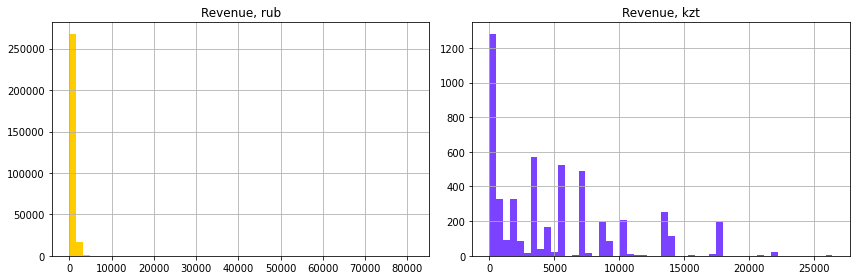

In [19]:
# Строим гистограммы распределения revenue отдельно по валютам
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.loc[rub_mask, 'revenue'].hist(
    bins=50, 
    ax=axes[0],
    color='#FFCC00'
)
axes[0].set_title('Revenue, rub')

df.loc[kzt_mask, 'revenue'].hist(
    bins=50, 
    ax=axes[1],
    color = '#7B42FF'
)
axes[1].set_title('Revenue, kzt')
plt.tight_layout()
plt.show()

Cтатистика и гистограммы показывают, что распределение revenue сильно смещено вправо - медиана намного меньше максимума (для рублей медиана 346, максимум 81 174), с длинным правым хвостом из редких дорогих заказов, что типично для выручки и требует отдельной обработки выбросов. Также встречаются отрицательные значения revenue (минимум −90,76 у рублей) - вероятно, это возвраты/корректировки заказов. Распределения по валютам заметно отличаются по масштабу (медиана в тенге ≈3699 против ≈347 в рублях - из-за разницы курса), поэтому выбросы нужно отбирать по 99-му процентилю раздельно для каждой валюты.

In [20]:
# Отбираем выбросы по 99-му процентилю отдельно для каждой валюты
rub_threshold = df.loc[rub_mask, 'revenue'].quantile(0.99)
kzt_threshold = df.loc[kzt_mask, 'revenue'].quantile(0.99)
print('99-й процентиль revenue, rub:', rub_threshold)
print('99-й процентиль revenue, kzt:', kzt_threshold)

keep_rub = rub_mask & (df['revenue'] <= rub_threshold)
keep_kzt = kzt_mask & (df['revenue'] <= kzt_threshold)

print('Отфильтровано rub:', rub_mask.sum() - keep_rub.sum(), 'заказов')
print('Отфильтровано kzt:', kzt_mask.sum() - keep_kzt.sum(), 'заказов')

df = df[keep_rub | keep_kzt].reset_index(drop=True)
df.shape

99-й процентиль revenue, rub: 2570.8
99-й процентиль revenue, kzt: 17617.24
Отфильтровано rub: 2800 заказов
Отфильтровано kzt: 29 заказов


(287782, 24)

In [21]:
# Смотрим на распределение tickets_count
print(df['tickets_count'].describe())
df['tickets_count'].value_counts().sort_index()

count    287782.000000
mean          2.740217
std           1.162477
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64


1     41787
2     83649
3     91703
4     53719
5     12839
6      3905
7        58
8        18
9        38
10       19
11       13
12        3
13        7
14        4
15        2
17        6
19        5
27        2
30        2
37        1
47        1
57        1
Name: tickets_count, dtype: int64

Выручка с заказа (revenue) имела выраженный правый хвост - редкие высокие значения на фоне основной массы заказов. По 99-му процентилю, отдельно для рублей (2570,8) и тенге (17617,24), отфильтровано 2800 и 29 заказов соответственно; итоговый датафрейм - 287 782 строки. Количество билетов в заказе (tickets_count) в основном находится в диапазоне 1–6 (свыше 99% заказов), встречаются единичные заказы на 7–57 билетов - они немногочисленны и похожи на реальные групповые покупки, а не на ошибки, поэтому отдельная фильтрация по этому признаку не проводилась.

### 2.5 Проверка дубликатов

In [22]:
# Проверяем явные дубликаты 
print('Явные дубликаты:', df.duplicated().sum())

Явные дубликаты: 0


In [23]:
# Проверяем неявные дубликаты - одно и то же бронирование без учёта order_id
subset_cols = ['user_id', 'created_ts_msk', 'event_id', 'tickets_count', 'total']
dupl = df.duplicated(subset=subset_cols).sum()
print('Неявные дубликаты:', dupl)

Неявные дубликаты: 43


In [24]:
# Смотрим на сами неявные дубликаты
df[df.duplicated(subset=subset_cols, keep=False)].sort_values(subset_cols).head(10)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
11643,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
11644,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
12557,5593202,08199117318954f,2024-07-31,2024-07-31 11:52:06,553623,нет,18,rub,mobile,0.00,...,8aa79719-8122-4b50-ae2a-fa484d034c5c,событие,другое,№4549,Каменевский регион,Глиногорск,213.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
12558,5592970,08199117318954f,2024-07-31,2024-07-31 11:52:06,553623,нет,18,rub,desktop,0.00,...,8aa79719-8122-4b50-ae2a-fa484d034c5c,событие,другое,№4549,Каменевский регион,Глиногорск,213.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
26648,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,b33d7a0b-a715-47e3-803e-02482884a73e,концерт,концерты,№5048,Каменевский регион,Глиногорск,213.0,2704.0,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43"
26650,1930763,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,b33d7a0b-a715-47e3-803e-02482884a73e,концерт,концерты,№5048,Каменевский регион,Глиногорск,213.0,2704.0,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43"
51119,5378312,1f49b8de206b285,2024-10-01,2024-10-01 11:32:40,574431,нет,0,rub,desktop,155.99,...,d4344522-b7cf-4539-96c8-efece75e9b16,спорт,спорт,№1531,Медовская область,Радужсвет,47.0,2157.0,"Студия дизайна ""Платформа"" Инкорпорэйтед","наб. Магистральная, д. 5"
51160,2968673,1f49b8de206b285,2024-10-01,2024-10-01 11:32:40,574431,нет,0,rub,mobile,155.99,...,d4344522-b7cf-4539-96c8-efece75e9b16,спорт,спорт,№1531,Медовская область,Радужсвет,47.0,2157.0,"Студия дизайна ""Платформа"" Инкорпорэйтед","наб. Магистральная, д. 5"
53203,1935113,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,...,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерт,концерты,№894,Каменевский регион,Глиногорск,213.0,4363.0,"Студия дизайна ""Лестница"" Лимитед","наб. Школьная, д. 9/8 стр. 7/5"
53205,1935171,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,...,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерт,концерты,№894,Каменевский регион,Глиногорск,213.0,4363.0,"Студия дизайна ""Лестница"" Лимитед","наб. Школьная, д. 9/8 стр. 7/5"


Явных дубликатов не обнаружено. Неявных дубликатов - 43. Проверка отдельных пар показала, что все признаки в них полностью совпадают, различие только в order_id - это похоже на задвоение записи одного и того же заказа при выгрузке из SQL, а не на реальные повторные покупки. 
Удалим такие строки:

In [25]:
# Удаляем неявные дубликаты, оставляя первую запись
df = df.drop_duplicates(subset=subset_cols).reset_index(drop=True)

# Смотрим сколько осталось строк и столбцов после удаления
df.shape

(287739, 24)

После удаления неявных дубликатов итоговый датафрейм содержит 287 739 строк (было 287 782, удалено 43 задвоенные записи - заказы с одинаковыми пользователем, временем, событием и суммой, отличавшиеся только order_id)

### 2.6 Преобразование типов данных

Приведём даты (`created_dt_msk`, `created_ts_msk`) к типу `datetime` - это позволит
удобно работать с временными периодами и извлекать месяц/сезон. 

Также понизим разрядность числовых столбцов - это уменьшит объём памяти без потери данных.

In [26]:
# Приводим даты к типу datetime
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])

# Понижаем разрядность числовых столбцов там, где это возможно
df['order_id'] = pd.to_numeric(df['order_id'], downcast='integer')
df['event_id'] = pd.to_numeric(df['event_id'], downcast='integer')
df['age_limit'] = pd.to_numeric(df['age_limit'], downcast='integer')
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')
df['city_id'] = pd.to_numeric(df['city_id'], downcast='integer')
df['venue_id'] = pd.to_numeric(df['venue_id'], downcast='integer')

# Проверяем преобразование
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287739 entries, 0 to 287738
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287739 non-null  int32         
 1   user_id                 287739 non-null  object        
 2   created_dt_msk          287739 non-null  datetime64[ns]
 3   created_ts_msk          287739 non-null  datetime64[ns]
 4   event_id                287739 non-null  int32         
 5   cinema_circuit          287739 non-null  object        
 6   age_limit               287739 non-null  int8          
 7   currency_code           287739 non-null  object        
 8   device_type_canonical   287739 non-null  object        
 9   revenue                 287739 non-null  float64       
 10  service_name            287739 non-null  object        
 11  tickets_count           287739 non-null  int8          
 12  total                   287739

### 2.7 Создание новых столбцов

Приведём выручку к единой валюте - российскому рублю, используя курс тенге на дату заказа, а также добавим выручку с одного билета, месяц и сезон оформления заказа - эти столбцы понадобятся для дальнейшего анализа сезонности и динамики.

In [27]:
# Приводим дату в датафрейме с курсом к datetime
tenge_curs['data'] = pd.to_datetime(tenge_curs['data'])

In [28]:
# Присоединяем курс тенге к рублю по дате заказа
df_tenge = tenge_curs[['data', 'curs']].rename(columns={'data': 'created_dt_msk', 'curs': 'kzt_rate'})
df = df.merge(df_tenge, on='created_dt_msk', how='left')

In [29]:
# Проверяем, не появились ли пропуски в курсе у заказов в тенге
df[df['currency_code'] == 'kzt']['kzt_rate'].isna().sum()

0

In [30]:
# Создаём revenue_rub: для рублёвых заказов - без изменений,
# для тенге - переводим по курсу (курс дан на 100 тенге)
df['revenue_rub'] = df['revenue']
kzt_mask = df['currency_code'] == 'kzt'
df.loc[kzt_mask, 'revenue_rub'] = df.loc[kzt_mask, 'revenue'] * df.loc[kzt_mask, 'kzt_rate'] / 100

# Проверяем 
print(df[df['currency_code'] == 'rub'][['revenue', 'currency_code', 'revenue_rub']].head(5))
print()
print(df[df['currency_code'] == 'kzt'][['revenue', 'currency_code', 'kzt_rate', 'revenue_rub']].head(5))

   revenue currency_code  revenue_rub
0  1521.94           rub      1521.94
1   289.45           rub       289.45
2  1258.57           rub      1258.57
3     8.49           rub         8.49
4  1390.41           rub      1390.41

     revenue currency_code  kzt_rate  revenue_rub
70    518.10           kzt   19.0125    98.503762
88    347.18           kzt   18.9330    65.731589
95    328.77           kzt   18.5991    61.148261
453  7397.66           kzt   19.9833  1478.296591
454  3698.83           kzt   19.9833   739.148295


In [31]:
# Считаем выручку с продажи одного билета
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

df['one_ticket_revenue_rub']

0         380.485000
1         144.725000
2         314.642500
3           4.245000
4         463.470000
             ...    
287734    241.392500
287735    241.393333
287736     89.475000
287737    330.765000
287738    401.125000
Name: one_ticket_revenue_rub, Length: 287739, dtype: float64

Создаем столбец `season` с информацией о сезонности, включая такие категории, как: лето, осень, зима, весна 

In [32]:
# Выделяем месяц оформления заказа
df['month'] = df['created_dt_msk'].dt.month
# Добавляем сезон оформления заказа
def get_season(month):
    if month in (12, 1, 2):
        return 'зима'
    elif month in (3, 4, 5):
        return 'весна'
    elif month in (6, 7, 8):
        return 'лето'
    else:
        return 'осень'

df['season'] = df['month'].apply(get_season)
df['season'].value_counts()

осень    168623
лето     119116
Name: season, dtype: int64

**Вывод по 2 разделу:**
- Данные объединены в единый датафрейм `df`. После объединения 238 заказов остались без информации о мероприятии - эти события отсутствовали в справочнике `events_info`, такие строки удалены.
- Пропусков в остальных столбцах не обнаружено, кроме ожидаемого `days_since_prev` у пользователей без истории покупок.
- Категориальные значения проверены - ошибок и скрытых пропусков не выявлено, нормализация не потребовалась.
- В `revenue` обнаружен выраженный правый хвост значений - по 99-му процентилю (отдельно для рублей и тенге) отфильтровано 2829 заказов. В `tickets_count` аномалий не выявлено.
- Обнаружено и удалено 43 неявных дубликата бронирований (одинаковые пользователь, время, событие и сумма при разных `order_id`).
- Типы данных приведены к корректным (datetime для дат, понижена разрядность числовых столбцов).
- Добавлены новые столбцы:
`revenue_rub` - выручка, приведённая к единой валюте (российскому рублю);
`one_ticket_revenue_rub` - выручка с продажи одного билета;
`month` - месяц оформления заказа;
`season` - сезон оформления заказа (в данных представлены только «лето» и «осень», так как период данных ограничен 01.06.2024-31.10.2024).
- Итоговый датафрейм содержит 287 739 строк.

## 3. Исследовательский анализ данных

### 3.1 Анализ распределения заказов по сегментам и их сезонные изменения

Проверим, действительно ли количество заказов растёт от лета к осени, и как распределяются заказы по типу мероприятия, типу устройства и возрастному рейтингу в разные сезоны.

In [33]:
# Считаем количество заказов по месяцам
orders_by_month = df.groupby('month')['order_id'].count()
orders_by_month

month
6     34164
7     40404
8     44548
9     69350
10    99273
Name: order_id, dtype: int64

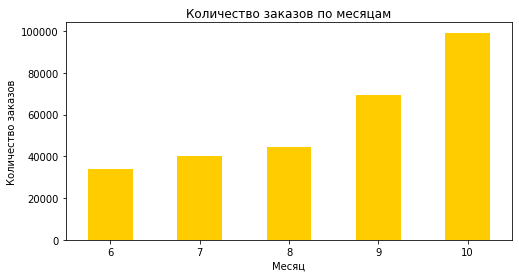

In [34]:
# Визуализируем динамику заказов по месяцам
orders_by_month.plot(kind='bar', figsize=(8, 4), color='#FFCC00', rot=0)
plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')
plt.show()

Количество заказов стабильно растёт от лета к осени - с 34 164 в июне до 99 273 в октябре (почти в 3 раза). Наиболее заметный скачок происходит в сентябре и продолжается в октябре.

In [35]:
# Доля заказов по типу мероприятия
event_type_shares = pd.crosstab(df['season'], df['event_type_main'], normalize='index')
event_type_shares

event_type_main,выставки,другое,концерты,спорт,стендап,театр,ёлки
season,,,,,,,
лето,0.020283,0.271718,0.426190,0.025236,0.053276,0.201006,0.002292
осень,0.014446,0.197037,0.372049,0.111960,0.041056,0.253423,0.010028


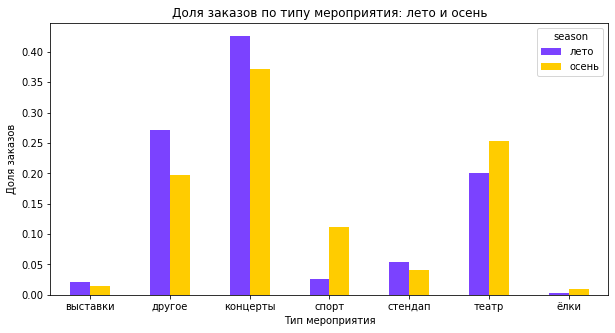

In [36]:
# Визуализируем сравнение долей по типу мероприятия
event_type_shares.T.plot(kind='bar', figsize=(10, 5), color=['#7B42FF', '#FFCC00'])

plt.title('Доля заказов по типу мероприятия: лето и осень')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля заказов')
plt.xticks(rotation=0)
plt.show()

Доля концертов немного снизилась осенью (с 43% до 37%), а доля спорта заметно выросла (с 2,5% до 11,2% - почти в 4,5 раза) и доля театра тоже подросла (с 20% до 25%). Категория «другое» сократилась (с 27% до 20%), доли выставок и стендапа изменились незначительно, доля ёлок выросла с почти нулевой до 1%(осенью начинают появляться предновогодние мероприятия)

In [37]:
# Доля заказов по типу устройства
device_shares = pd.crosstab(df['season'], df['device_type_canonical'], normalize='index')
device_shares

device_type_canonical,desktop,mobile
season,,
лето,0.193576,0.806424
осень,0.203430,0.796570


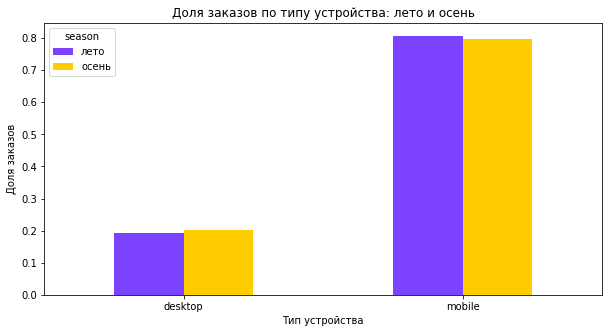

In [38]:
# Визуализируем сравнение долей по типу устройства
device_shares.T.plot(kind='bar', figsize=(10, 5), color=['#7B42FF', '#FFCC00'])

plt.title('Доля заказов по типу устройства: лето и осень')
plt.xlabel('Тип устройства')
plt.ylabel('Доля заказов')
plt.xticks(rotation=0)

plt.show()

Распределение по типу устройства практически не изменилось между сезонами - мобильные устройства стабильно доминируют (≈80% заказов) как летом, так и осенью, разница в пределах 1 процентного пункта.

In [39]:
# Доля заказов по возрастному рейтингу
age_shares = pd.crosstab(df['season'], df['age_limit'], normalize='index')
age_shares

age_limit,0,6,12,16,18
season,,,,,
лето,0.179674,0.181949,0.205380,0.283379,0.149619
осень,0.236184,0.176245,0.220978,0.262206,0.104387


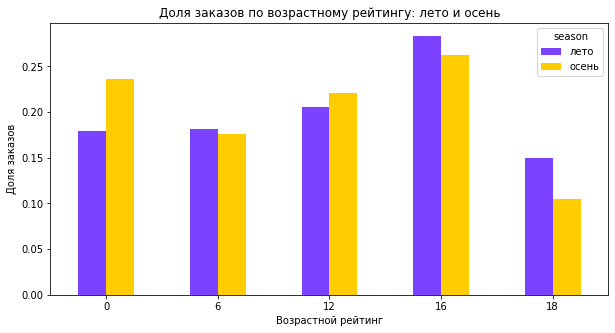

In [40]:
# Визуализируем сравнение долей по возрастному рейтингу
age_shares.T.plot(kind='bar', figsize=(10, 5), color=['#7B42FF', '#FFCC00'])

plt.title('Доля заказов по возрастному рейтингу: лето и осень')
plt.xlabel('Возрастной рейтинг')
plt.ylabel('Доля заказов')
plt.xticks(rotation=0)

plt.show()

Осенью выросла доля заказов без возрастных ограничений (0+) - с 18% до 24%, при этом заметно снизилась доля заказов 18+ (с 15% до 10%). Доли категорий 6+ и 12+ практически не изменились, 16+ немного снизилась. В целом видно, что осенью аудитория смещается в сторону более семейных/детских мероприятий.

- Посчитаем среднюю выручку с одного билета для каждого типа мероприятия отдельно летом и осенью, а также относительное изменение осенних значений по сравнению с летними.

In [41]:
# Средняя выручка с одного билета по типу мероприятия и сезону
avg_ticket_revenue = df.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub'].mean().unstack()
avg_ticket_revenue

season,лето,осень
event_type_main,,
выставки,86.416198,90.603610
другое,77.439799,76.115334
концерты,304.785459,268.360658
спорт,50.761831,49.970896
стендап,218.518107,231.124973
театр,214.138855,175.977088
ёлки,271.436176,229.585589


In [42]:
# Относительное изменение осени к лету
avg_ticket_revenue['change'] = (avg_ticket_revenue['осень'] - avg_ticket_revenue['лето']) / avg_ticket_revenue['лето']
avg_ticket_revenue

season,лето,осень,change
event_type_main,,,
выставки,86.416198,90.603610,0.048456
другое,77.439799,76.115334,-0.017103
концерты,304.785459,268.360658,-0.119510
спорт,50.761831,49.970896,-0.015581
стендап,218.518107,231.124973,0.057693
театр,214.138855,175.977088,-0.178210
ёлки,271.436176,229.585589,-0.154182


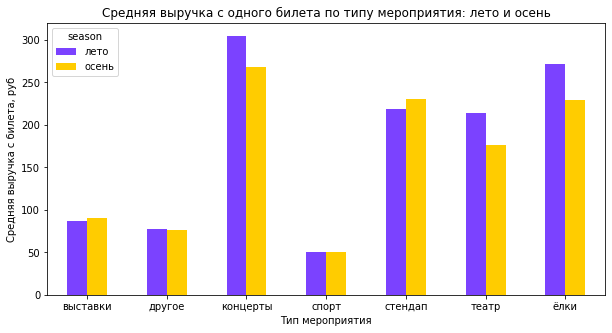

In [43]:
# Визуализируем среднюю выручку с билета по сезонам
avg_ticket_revenue[['лето', 'осень']].plot(kind='bar', figsize=(10, 5), color=['#7B42FF', '#FFCC00'])

plt.title('Средняя выручка с одного билета по типу мероприятия: лето и осень')
plt.xlabel('Тип мероприятия')
plt.ylabel('Средняя выручка с билета, руб')
plt.xticks(rotation=0)

plt.show()

**Средняя выручка с одного билета осенью снизилась** в большинстве категорий мероприятий:
- cильнее всего просела у театра (-18%) и ёлок (-15%), заметно снизилась и у концертов (-12%) - а это самая массовая категория по числу заказов, что и объясняет общий тренд к снижению средней стоимости заказа. Спорт и «другое» изменились незначительно (в пределах 2%); 
- выросла выручка с билета только у выставок (+5%) и стендапа (+6%), но обе категории занимают небольшую долю в общем объёме заказов, поэтому на общую картину они почти не влияют.

**Вывод по разделу 3.1:**

- Количество заказов стабильно растёт от лета к осени - почти в 3 раза (с 34 164 в июне до 99 273 в октябре
- В структуре заказов по типу мероприятия доля концертов и театра осенью немного снизилась, зато доля спорта выросла почти в 4,5 раза, а доля «ёлок» - с почти нулевой до 1%.
- Распределение по типу устройства почти не изменилось - мобильные устройства стабильно составляют ≈80% заказов в оба сезона.
- В возрастных категориях осенью выросла доля заказов без ограничений (0+), а доля 18+ заметно снизилась - аудитория смещается к более семейным/массовым мероприятиям.
- Средняя выручка с одного билета осенью снизилась почти во всех категориях, сильнее всего - у театра и ёлок, а также у концертов (самой массовой категории).

Таким образом, снижение средней стоимости заказа объясняется не одной причиной, а сочетанием двух эффектов: смещением структуры заказов в сторону более доступных категорий (спорт, 0+) и снижением цены билета внутри самих категорий (особенно у театра и концертов).

### 3.2 Осенняя активность пользователей

Для этого раздела используем только данные за осенние месяцы - сентябрь и октябрь.

In [44]:
# Оставляем только данные за осень
autumn_df = df[df['season'] == 'осень']
autumn_df.shape

(168623, 29)

Построим сводную таблицу по дням: число заказов, число уникальных пользователей (DAU), среднее число заказов на одного пользователя и среднюю стоимость одного билета.

In [45]:
daily_stats = autumn_df.groupby('created_dt_msk').agg(
    orders_count=('order_id', 'count'),
    dau=('user_id', 'nunique'),
    avg_ticket_revenue=('one_ticket_revenue_rub', 'mean')
)
daily_stats['orders_per_user'] = daily_stats['orders_count'] / daily_stats['dau']
daily_stats

,orders_count,dau,avg_ticket_revenue,orders_per_user
created_dt_msk,,,,
2024-09-01,1327,564,200.168708,2.352837
2024-09-02,1380,574,189.464639,2.404181
2024-09-03,5113,778,80.350151,6.571979
2024-09-04,1773,686,178.048069,2.584548
2024-09-05,1944,739,189.510156,2.630582
...,...,...,...,...
2024-10-27,2849,1034,186.968328,2.755319
2024-10-28,2838,985,170.654940,2.881218
2024-10-29,2835,998,177.366072,2.840681


Визуализируем полученные результаты

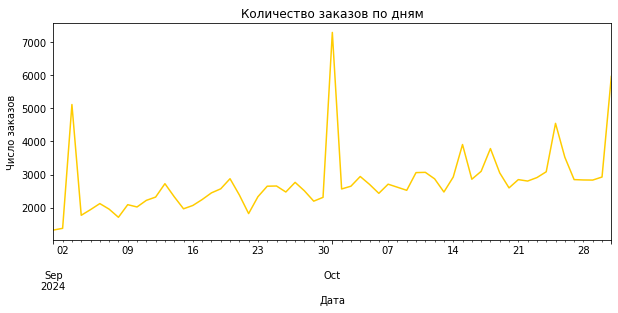

In [46]:
# Общее число заказов по дням
daily_stats['orders_count'].plot(figsize=(10, 4), color='#FFCC00')
plt.title('Количество заказов по дням')
plt.ylabel('Число заказов')
plt.xlabel('Дата')
plt.show()

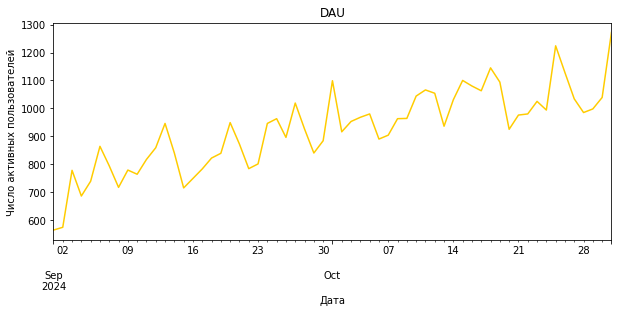

In [47]:
# Общее число уникальных пользователей (DAU)
daily_stats['dau'].plot(figsize=(10, 4), color='#FFCC00')
plt.title('DAU')
plt.ylabel('Число активных пользователей')
plt.xlabel('Дата')
plt.show()

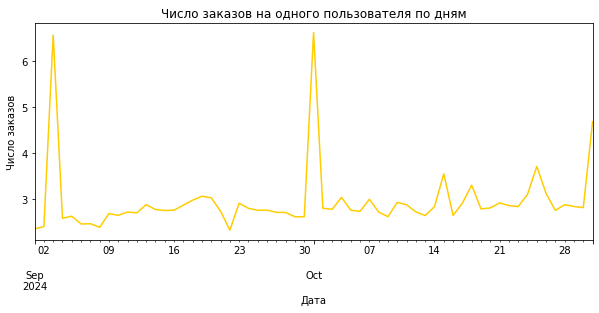

In [48]:
# Среднее число заказов
daily_stats['orders_per_user'].plot(figsize=(10, 4), color='#FFCC00')
plt.title('Число заказов на одного пользователя по дням')
plt.ylabel('Число заказов')
plt.xlabel('Дата')
plt.show()

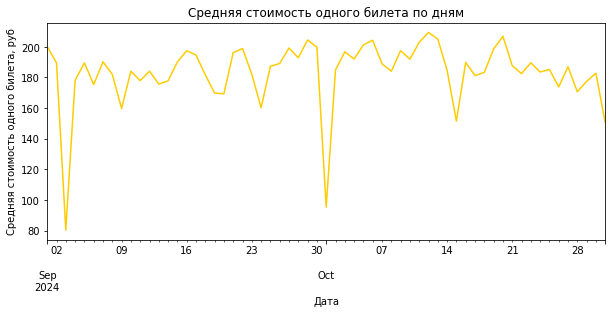

In [49]:
# Средняя стоимость одного билета
daily_stats['avg_ticket_revenue'].plot(figsize=(10, 4), color='#FFCC00')
plt.title('Средняя стоимость одного билета по дням')
plt.ylabel('Средняя стоимость одного билета, руб')
plt.xlabel('Дата')
plt.show()

За осенний период видна общая тенденция роста активности - и число заказов (с 1300 до 5960), и DAU заметно выше в конце октября, чем в начале сентября (DAU вырос примерно с 560 - 740 до 1000+). Также заметны резкие всплески в отдельные дни (3 сентября и 31 октября - заказов в 2 - 4 раза больше обычного), при этом средняя стоимость билета в эти дни падает, а число заказов на пользователя растёт - похоже на акции/распродажи или крупные разовые мероприятия.

- Изучим недельную цикличность


In [50]:
# Выделяем день недели из даты
daily_stats['weekday'] = daily_stats.index.day_name()

# Помечаем будни и выходные дни
daily_stats['is_weekend'] = daily_stats.index.weekday >= 5

In [51]:
# Вычисляем средние показатели по дням недели
weekday_stats = daily_stats.groupby('weekday')[['orders_count', 'dau', 'orders_per_user', 'avg_ticket_revenue']].mean()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_stats = weekday_stats.reindex(weekday_order)
weekday_stats

,orders_count,dau,orders_per_user,avg_ticket_revenue
weekday,,,,
Monday,2390.333333,853.666667,2.780084,184.493560
Tuesday,3498.555556,934.555556,3.721904,156.671430
Wednesday,2543.444444,923.555556,2.752209,185.486556
Thursday,3018.333333,962.111111,3.063960,181.812119
Friday,3104.375000,1022.625000,3.003061,185.355975
Saturday,2667.625000,961.000000,2.761247,192.498857
Sunday,2154.555556,822.777778,2.598522,197.636651


In [52]:
# Сравниваем активность в будни и выходные
weekend_stats = daily_stats.groupby('is_weekend')[['orders_count', 'dau', 'orders_per_user', 'avg_ticket_revenue']].mean()
weekend_stats.index = ['Будни', 'Выходные']
weekend_stats

,orders_count,dau,orders_per_user,avg_ticket_revenue
Будни,2906.613636,937.409091,3.065634,178.614109
Выходные,2396.000000,887.823529,2.675099,195.218865


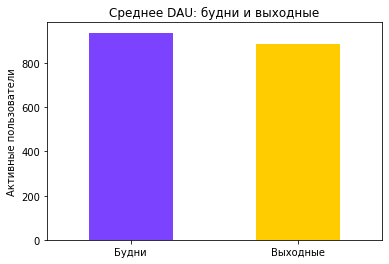

In [53]:
# Визуализация: DAU в будни и выходные
weekend_stats['dau'].plot(kind='bar', figsize=(6, 4), color=['#7B42FF', '#FFCC00'])
plt.title('Среднее DAU: будни и выходные')
plt.ylabel('Активные пользователи')
plt.xticks(rotation=0)
plt.show()

**Вывод:**
- За осенний период активность выросла: и число заказов, и DAU заметно выше в конце октября, чем в начале сентября (DAU вырос примерно с 560 - 740 до 1000+). В отдельные дни (3 сентября, 31 октября) заметны резкие всплески - в 2 - 4 раза больше обычного, вероятно, акции или крупные мероприятия.
- По дням недели заказов больше во вторник, четверг и пятницу - DAU стабильно выше в будни (922–1022) и заметно ниже в воскресенье (823) и понедельник (854).
- В будни показатели выше, чем в выходные: в среднем больше заказов (2907 против 2396) и выше DAU (937 против 888), заказов на пользователя тоже больше (3,07 против 2,68). При этом средняя стоимость билета в выходные выше (195 против 179 руб.) - то есть люди делают в выходные меньше заказов, но более дорогих.

### 3.3. Популярные события и партнёры

Посмотрим, как события распределены по регионам и партнёрам. Это позволит выделить ключевые регионы и партнёров, которые вносят наибольший вклад в выручку.

In [54]:
# Для каждого региона считаем число уникальных мероприятий и общее число заказов
top_regions = df.groupby('region_name').agg(
    event_count=('event_id', 'nunique'),
    orders_count=('order_id', 'count')
)

# Добавляем доли от общего числа мероприятий и заказов
top_regions['event_share'] = top_regions['event_count'] / top_regions['event_count'].sum()
top_regions['orders_share'] = top_regions['orders_count'] / top_regions['orders_count'].sum()

top_regions = top_regions.sort_values('event_count', ascending=False)
top_regions.head(10)

,event_count,orders_count,event_share,orders_share
region_name,,,,
Каменевский регион,5935,89660,0.265441,0.311602
Североярская область,3800,43738,0.169954,0.152006
Широковская область,1232,16169,0.055101,0.056193
Светополянский округ,1075,7501,0.048079,0.026069
Речиновская область,702,6266,0.031397,0.021777
Травяная область,683,5036,0.030547,0.017502
Горицветская область,551,5152,0.024643,0.017905
Серебринская область,541,5586,0.024196,0.019413
Яблоневская область,535,6123,0.023928,0.021280


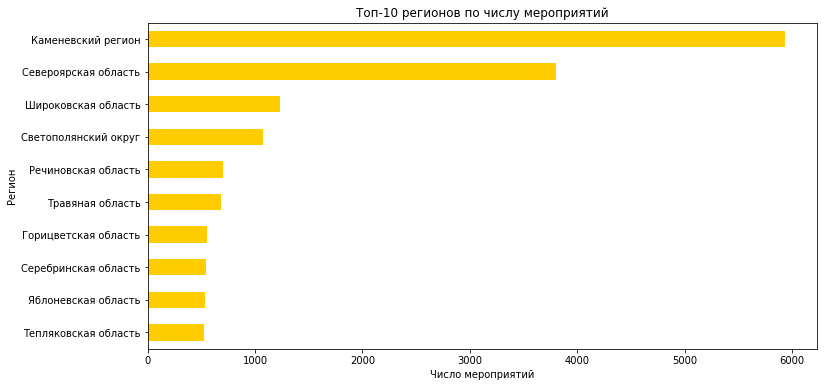

In [55]:
# Визуализируем топ-10 регионов по числу мероприятий
top_regions.head(10)['event_count'].sort_values().plot(
    kind='barh',
    color = '#FFCC00',
    figsize=(12, 6)
)

plt.title('Топ-10 регионов по числу мероприятий')
plt.xlabel('Число мероприятий')
plt.ylabel('Регион')
plt.show()

Мероприятия и заказы распределены по регионам очень неравномерно, с явными двумя лидерами:
- Каменевский регион занимает первое место с большим отрывом - почти треть всех заказов (31%) и четверть мероприятий (26,5%).
- На втором месте - Североярская область (заказы - 15%, мероприятия - 17%). 
- Оставшиеся регионы из топ-10 уже гораздо скромнее - их доли не превышают 6%, а совокупно на два региона-лидера приходится почти половина всей активности платформы.

In [56]:
# Для каждого партнера считаем число уникальных мероприятий, число заказов и суммарную выручку
top_partner = df.groupby('service_name').agg(
    event_count=('event_id', 'nunique'),
    orders_count=('order_id', 'count'),
    revenue_sum=('revenue_rub', 'sum')
)

# Добавляем доли от общего числа мероприятий и заказов
top_partner['event_share'] = top_partner['event_count'] / top_partner['event_count'].sum()
top_partner['orders_share'] = top_partner['orders_count'] / top_partner['orders_count'].sum()
top_partner['revenue_share'] = top_partner['revenue_sum'] / top_partner['revenue_sum'].sum()

top_partner = top_partner.sort_values('revenue_sum', ascending=False)
top_partner.head(10)

,event_count,orders_count,revenue_sum,event_share,orders_share,revenue_share
service_name,,,,,,
Билеты без проблем,4247,62855,2.432207e+07,0.174164,0.218444,0.162956
Мой билет,1300,34438,2.204190e+07,0.053311,0.119685,0.147679
Облачко,2335,26402,1.858861e+07,0.095756,0.091757,0.124542
Лови билет!,4867,40800,1.667385e+07,0.199590,0.141795,0.111714
Весь в билетах,855,16424,1.653235e+07,0.035063,0.057080,0.110766
Билеты в руки,3530,40277,1.319345e+07,0.144761,0.139978,0.088395
Край билетов,252,6109,6.405689e+06,0.010334,0.021231,0.042918
Прачечная,1026,10222,4.746811e+06,0.042075,0.035525,0.031803
Дом культуры,272,4412,4.358656e+06,0.011154,0.015333,0.029203


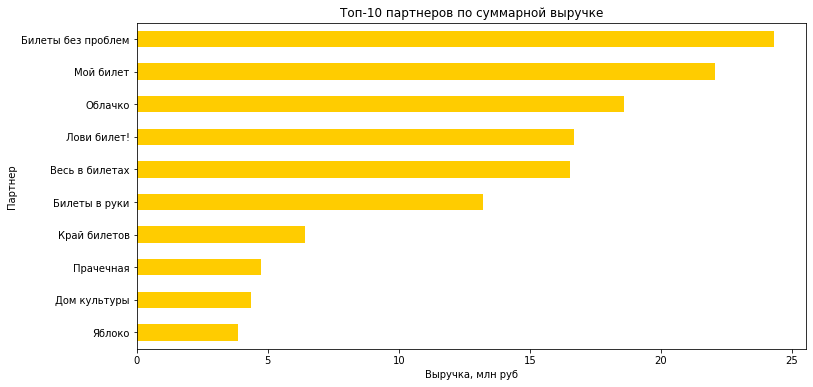

In [57]:
# Визуализируем топ-10 партнеров по выручке
(top_partner.head(10)['revenue_sum'] / 1_000_000).sort_values().plot(
    kind='barh',
    color = '#FFCC00',
    figsize=(12, 6)
)

plt.title('Топ-10 партнеров по суммарной выручке')
plt.xlabel('Выручка, млн руб')
plt.ylabel('Партнер')
plt.show()

Выручка распределена по партнёрам неравномерно, но без одного явного доминирующего лидера - топ-6 партнёров формируют около 75% всей выручки, а оставшиеся партнёры делят между собой лишь малые доли. 
- Лидер по выручке - «Билеты без проблем» (16,3%), за ним «Мой билет» (14,8%) и «Облачко» (12,5%). 

При этом лидерство по числу мероприятий не совпадает с лидерством по выручке: «Лови билет!» проводит больше всего мероприятий (20% от общего числа), но по выручке лишь на 4-м месте - а «Мой билет», наоборот, работает с гораздо меньшим числом мероприятий, но зарабатывает почти столько же, сколько лидер. Это говорит о разной эффективности партнеров, а не только о масштабе их присутствия на платформе.

**Вывод по разделу 3.3:**

- И среди регионов, и среди партнеров есть явные лидеры, но характер лидерства разный:

**Среди регионов** - это концентрация в одной точке: Каменевский регион и Североярская область вместе дают почти половину всей активности платформы, а остальные 79+ регионов делят между собой оставшуюся половину небольшими долями (максимум 6% на регион).

**Среди партнёров** лидерство более распределенное: топ-6 партнеров формируют около 75% выручки, но при этом нет одного доминирующего игрока - есть разрыв между эффективностью (выручка на мероприятие) и масштабом (число мероприятий): например, «Лови билет!» лидирует по количеству событий, но не по выручке, а «Мой билет» - наоборот, меньше событий, но выручка выше.

- Во-первых, стоит изучить опыт двух регионов-лидеров и понять, что помогает им привлекать больше мероприятий - возможно, эту практику получится применить и в других регионах.
- Во-вторых, партнёры вроде «Мой билет», которые зарабатывают много при меньшем числе мероприятий, работают эффективнее остальных - стоит разобраться, за счёт чего (более дорогие мероприятия, лучшая конверсия в заказы), и посмотреть, можно ли этот подход распространить на менее эффективных партнёров.

## 4. Статистический анализ данных

### 4.1 Среднее количество заказов на одного пользователя, мобильные и стационарные устройства

**H0:** среднее количество заказов на одного пользователя не отличается между мобильными и стационарными устройствами.<br>
**H1:** среднее количество заказов на одного пользователя у мобильных устройств выше, чем у стационарных.

In [58]:
# Считаем число заказов на каждого пользователя осенью, с указанием типа устройства
user_device = autumn_df.groupby('user_id')['device_type_canonical'].first()
orders_per_user_device = autumn_df.groupby('user_id')['order_id'].count()

user_orders = pd.DataFrame({
    'orders_count': orders_per_user_device,
    'device_type': user_device
})
user_orders.head(10)

,orders_count,device_type
user_id,,
0005ca5e93f2cf4,1,mobile
000898990054619,2,mobile
000a55a418c128c,2,mobile
001e7037d013f0f,2,mobile
00245c702bc343e,2,mobile
0028d17a676f8c8,2,desktop
002b75ca606ba46,4,mobile
002ec276eee9b0b,12,desktop
0033403583a55ed,1,mobile


In [59]:
# Разделяем на две выборки
mobile_orders = user_orders[user_orders['device_type'] == 'mobile']['orders_count']
desktop_orders = user_orders[user_orders['device_type'] == 'desktop']['orders_count']

print('mobile:', mobile_orders.shape[0], 'пользователей, среднее:', mobile_orders.mean())
print('desktop:', desktop_orders.shape[0], 'пользователей, среднее:', desktop_orders.mean())

mobile: 13199 пользователей, среднее: 10.888021819834837
desktop: 2612 пользователей, среднее: 9.537519142419601


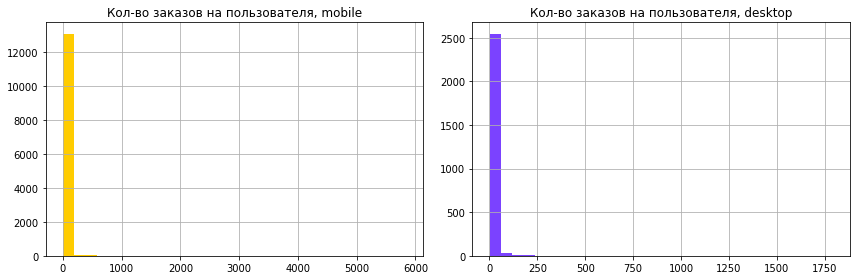

In [60]:
# Смотрим на распределение количества заказов в обеих группах
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mobile_orders.hist(
    bins=30, 
    ax=axes[0],
    color='#FFCC00'
)
axes[0].set_title('Кол-во заказов на пользователя, mobile')

desktop_orders.hist(
    bins=30, 
    ax=axes[1],
    color='#7B42FF'
)
axes[1].set_title('Кол-во заказов на пользователя, desktop')
plt.tight_layout()
plt.show()

In [61]:
# Точные статистики по числу заказов, отдельно для mobile и desktop
print('mobile:')
print(mobile_orders.describe())
print()
print('desktop:')
print(desktop_orders.describe())

mobile:
count    13199.000000
mean        10.888022
std         88.188701
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       5835.000000
Name: orders_count, dtype: float64

desktop:
count    2612.000000
mean        9.537519
std        49.876436
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max      1790.000000
Name: orders_count, dtype: float64


Распределение количества заказов на одного пользователя в обеих группах сильно скошено вправо: медиана в обеих группах равна 2, при этом среднее заметно выше (10,89 у mobile и 9,54 у desktop) Кроме того, в данных присутствуют пользователи с очень большим количеством заказов (до 5835 заказов за два месяца), которые сильно искажают среднее значение. 

Поэтому для сравнения двух независимых групп используем непараметрический критерий Манна–Уитни, который не требует нормальности распределения

In [62]:
alpha = 0.05

results = stats.mannwhitneyu(
    mobile_orders, 
    desktop_orders, 
    alternative='greater')

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем H0')
else:
    print('Не получилось отвергнуть H0')

p-value: 0.9323560742440891
Не получилось отвергнуть H0


При уровне значимости α = 0.05 получили p-value = 0.932. Поскольку p-value > α, нулевую гипотезу не отвергаем. Статистически значимых оснований утверждать, что пользователи мобильных устройств совершают больше заказов, чем пользователи стационарных устройств, не обнаружено.

### 4.2 Среднее время между заказами, мобильные и стационарные устройства

**H0:** среднее время между заказами не отличается у пользователей мобильных и стационарных устройств.<br>
**H1:** среднее время между заказами у пользователей мобильных устройств выше, чем у пользователей стационарных.

Для этого у нас уже есть готовый столбец `days_since_prev` - количество дней с предыдущей покупки. У первой покупки пользователя это значение пропущено (NaN), такие строки для этого анализа не подходят и их нужно исключить.

In [63]:
# Берем заказы с известным временем с предыдущей покупки за осенний период
order_repeat = autumn_df.dropna(subset=['days_since_prev'])

# Разделяем на две выборки
mobile_order = order_repeat[order_repeat['device_type_canonical'] == 'mobile']['days_since_prev']
desktop_order = order_repeat[order_repeat['device_type_canonical'] == 'desktop']['days_since_prev']

print('mobile:', mobile_order.shape[0], 'заказов, среднее:', mobile_order.mean())
print('desktop:', desktop_order.shape[0], 'заказов, среднее:', desktop_order.mean())

mobile: 127332 заказов, среднее: 3.7788144378475166
desktop: 32945 заказов, среднее: 3.025254211564729


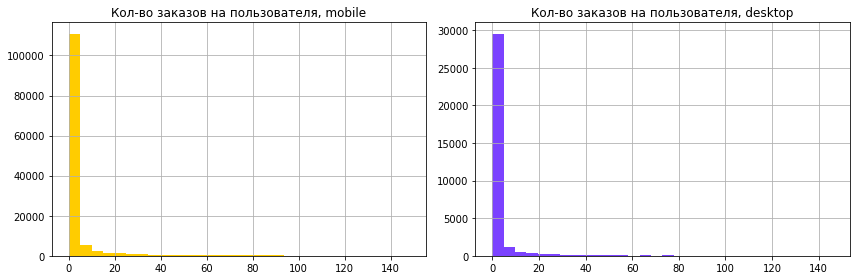

In [64]:
# Смотрим на распределение в обеих группах
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mobile_order.hist(
    bins=30, 
    ax=axes[0],
    color='#FFCC00'
)
axes[0].set_title('Кол-во заказов на пользователя, mobile')

desktop_order.hist(
    bins=30, 
    ax=axes[1],
    color='#7B42FF'
)
axes[1].set_title('Кол-во заказов на пользователя, desktop')
plt.tight_layout()
plt.show()

In [65]:
# Точные статистики по времени между заказами, отдельно для mobile и desktop
print('mobile:')
print(mobile_order.describe())
print()
print('desktop:')
print(desktop_order.describe())

mobile:
count    127332.000000
mean          3.778814
std          13.382006
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         148.000000
Name: days_since_prev, dtype: float64

desktop:
count    32945.000000
mean         3.025254
std         12.095335
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        146.000000
Name: days_since_prev, dtype: float64


Распределение времени между заказами также сильно скошено вправо: медиана в обеих группах равна 0, при этом среднее заметно выше (3,78 дня у mobile против 3,03 у desktop) - большинство повторных покупок происходит в тот же день или на следующий, а редкие большие интервалы (до 148 дней) сдвигают среднее вверх. Данные не похожи на нормальноераспределение, поэтому здесь также используем непараметрический тест Манна-Уитни.

In [66]:
alpha = 0.05

result = stats.mannwhitneyu(
    mobile_order, 
    desktop_order, 
    alternative='greater')

print('p-value:', result.pvalue)

if result.pvalue < alpha:
    print('Отвергаем H0')
else:
    print('Не получилось отвергнуть H0')

p-value: 3.0780168622235886e-92
Отвергаем H0


При уровне значимости α = 0.05 получили p-value = 3.0780168622235886e-92. Поскольку p-value < α, нулевую гипотезу отвергаем. Среднее время между заказами у пользователей мобильных устройств статистически значимо выше, чем у пользователей стационарных устройств.

Таким образом, из двух гипотез продуктовой команды подтвердилась только вторая. Мобильные пользователи не показывают более высокую интенсивность заказов на человека, но интервал между их повторными покупками длиннее - то есть они возвращаются за новыми покупками реже, чем пользователи стационарных устройств, хотя суммарно на платформе мобильных пользователей значительно больше (13199 против 2612).

## 5. Общий вывод и рекомендации


- Информация о данных: 

анализировались бронирования билетов сервиса «Яндекс Афиша» за 01.06 - 31.10.2024 (два датасета - заказы и мероприятия, плюс курс тенге к рублю). После предобработки (удаление заказов без данных о мероприятии, отбор выбросов по выручке, удаление дубликатов) итоговый датафрейм - 287 739 строк.

- Основные результаты анализа:

Число заказов стабильно росло от лета к осени - почти в 3 раза (с 34 164 в июне до 99 273 в октябре), при этом средняя выручка с одного билета осенью снизилась почти во всех категориях мероприятий (сильнее всего - у театра и ёлок).
Причина снижения среднего чека - сочетание двух факторов: сместилась структура спроса (выросла доля более доступных категорий - спорт, мероприятия без возрастных ограничений) и упала цена билета внутри самих категорий (особенно у концертов и театра).
Мобильные устройства стабильно дают около 80% заказов в оба сезона - эта пропорция не меняется от сезонности.
Пользовательская активность осенью росла по всем метрикам (DAU, число заказов), с отдельными пиковыми днями (3 сентября, 31 октября). В будни активность выше, чем в выходные, но в выходные пользователи делают более дорогие заказы.
Среди регионов - два явных лидера (Каменевский регион и Североярская область), которые вместе дают почти половину всей активности платформы. Среди партнёров явного монополиста нет: топ-6 дают около 75% выручки, при этом масштаб (число мероприятий) не всегда определяет выручку - есть партнёры, работающие эффективнее конкурентов при меньшем масштабе.

- Результаты проверки гипотез:

Гипотеза о том, что мобильные пользователи делают больше заказов на человека, чем стационарные - не подтвердилась (p-value = 0,932).
Гипотеза о том, что у мобильных пользователей больше времени проходит между заказами - подтвердилась (p-value = 3.0780168622235886e-92).

Рекомендации:

- Разобраться в причинах снижения среднего чека и решить, устраивает ли компанию рост числа заказов за счёт более дешёвых категорий, или стоит стимулировать более дорогие сегменты (театр, концерты).
- Изучить опыт регионов-лидеров (Каменевский регион, Североярская область) и партнёров с высокой выручкой на мероприятие («Мой билет») - понять, что делает их успешнее, и посмотреть, применим ли этот опыт к остальным.
- Учитывая, что мобильные пользователи реже возвращаются за повторной покупкой (хотя суммарно их больше), стоит рассмотреть механики удержания именно для мобильного приложения (пуш-уведомления, персональные предложения о новых мероприятиях).
- Проверить природу аномально активных пользователей (до 5835 заказов за 2 месяца) - возможно, это боты или партнёрские закупки, которые стоит выделять отдельно при дальнейшем анализе.